In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
df = pd.read_excel("/content/Dataset for Data Analytics 2.xlsx")
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


# **data expolartion**

In [6]:
print("==" * 50)
print("data exploration")
print("=="*50)
print("columns:",df.columns)
print("==" * 50)
print("shape:",df.shape)
print("==" * 50)
print("description:",df.describe())
print("==" * 50)
print("information:",df.info())

data exploration
columns: Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')
shape: (1200, 14)
description:                       Date     Quantity    UnitPrice  ItemsInCart   TotalPrice
count                 1200  1200.000000  1200.000000  1200.000000  1200.000000
mean   2024-03-22 16:58:48     2.945833   356.412750     5.485000  1053.968300
min    2023-01-01 00:00:00     1.000000    11.390000     1.000000    11.390000
25%    2023-08-03 18:00:00     2.000000   186.062500     4.000000   410.520000
50%    2024-03-23 00:00:00     3.000000   364.210000     5.000000   823.615000
75%    2024-11-08 12:00:00     4.000000   521.570000     7.000000  1578.475000
max    2025-06-30 00:00:00     5.000000   699.930000    10.000000  3456.400000
std                    NaN     1.407557   197.177146     2.281983   

In [7]:
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


In [12]:
df['CouponCode'] = df['CouponCode'].fillna('No Coupon')
df['CouponCode']

,CouponCode
0,SAVE10
1,SAVE10
2,FREESHIP
3,SAVE10
4,SAVE10
...,...
1195,FREESHIP
1196,No Coupon
1197,FREESHIP
1198,WINTER15


In [15]:
print("==" * 50)
print("Basice Statistiques")
print("==" * 50)

df.describe()

Basice Statistiques


,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


# **Product Analysis**

In [16]:
df.groupby('Product')['TotalPrice'].sum()

,TotalPrice
Product,
Chair,195620.11
Desk,167459.93
Laptop,192126.56
Monitor,175651.41
Phone,151722.39
Printer,195612.61
Tablet,186568.95


In [17]:
df.groupby('Product')['Quantity'].sum()


,Quantity
Product,
Chair,562
Desk,508
Laptop,535
Monitor,480
Phone,411
Printer,542
Tablet,497


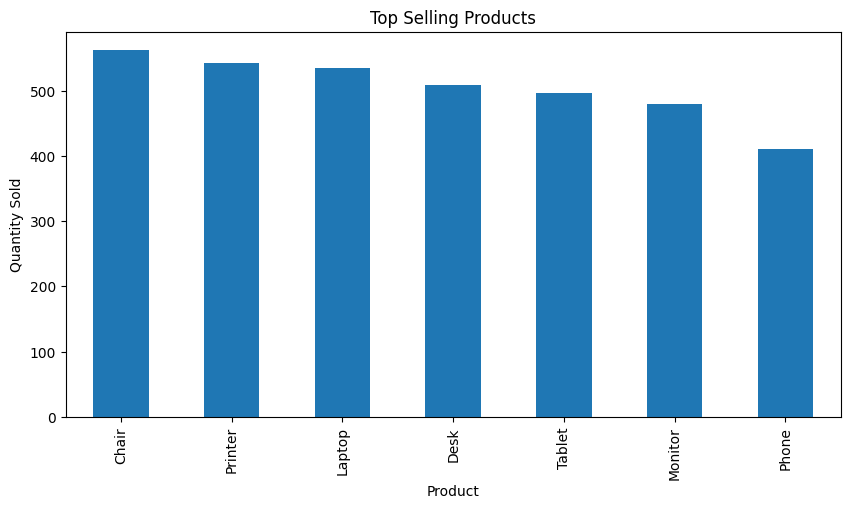

In [32]:
top_products = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False)

top_products.plot(kind='bar', figsize=(10,5))
plt.title('Top Selling Products')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')
plt.show()

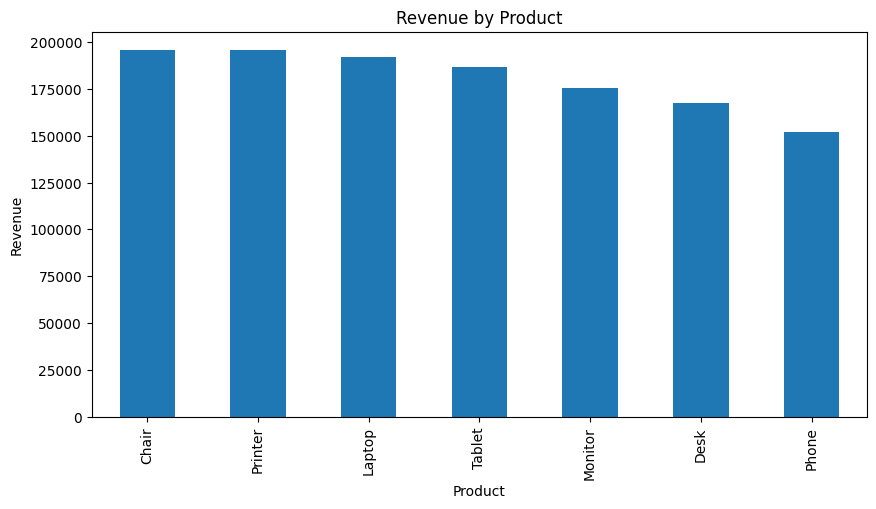

In [33]:
revenue_by_product = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)

revenue_by_product.plot(kind='bar', figsize=(10,5))
plt.title('Revenue by Product')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.show()

# **Payment Method analysis**

In [19]:
df.groupby('PaymentMethod')['TotalPrice'].sum()

,TotalPrice
PaymentMethod,
Cash,259786.29
Credit Card,263847.63
Debit Card,232361.18
Gift Card,246323.92
Online,262442.94


In [18]:
df['PaymentMethod'].value_counts()


,count
PaymentMethod,
Online,258
Cash,246
Credit Card,234
Debit Card,232
Gift Card,230


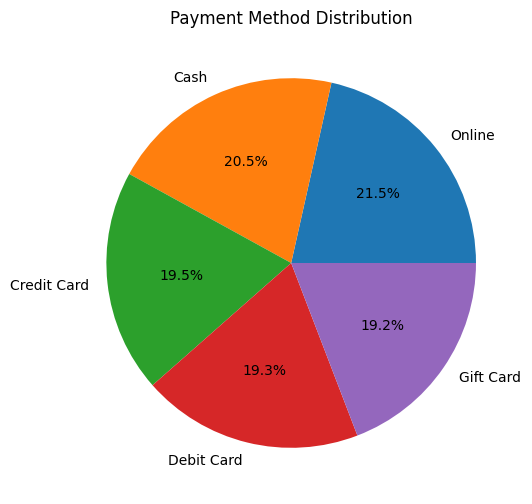

In [34]:
df['PaymentMethod'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)
plt.title('Payment Method Distribution')
plt.ylabel('')
plt.show()

# **Order Status Analysis**

In [20]:
df['OrderStatus'].value_counts()

,count
OrderStatus,
Cancelled,250
Returned,247
Pending,237
Shipped,235
Delivered,231


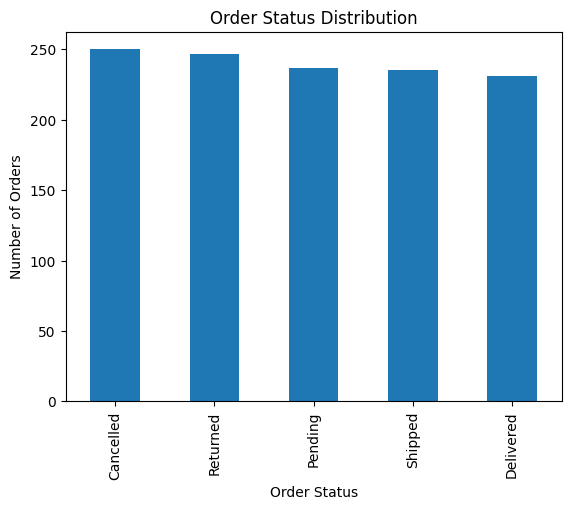

In [35]:
df['OrderStatus'].value_counts().plot(kind='bar')
plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.show()

# **coupond analysis**

In [21]:
df['CouponCode'].value_counts()

,count
CouponCode,
FREESHIP,313
No Coupon,309
WINTER15,292
SAVE10,286


In [22]:
df.groupby('CouponCode')['TotalPrice'].sum()

,TotalPrice
CouponCode,
FREESHIP,335036.99
No Coupon,322401.41
SAVE10,304840.02
WINTER15,302483.54


# **Referral Source Analysis**

In [23]:
df['ReferralSource'].value_counts()

,count
ReferralSource,
Instagram,259
Email,250
Google,241
Facebook,228
Referral,222


In [24]:
df.groupby('ReferralSource')['TotalPrice'].sum()

,TotalPrice
ReferralSource,
Email,261808.55
Facebook,250410.90
Google,250441.48
Instagram,275285.45
Referral,226815.58


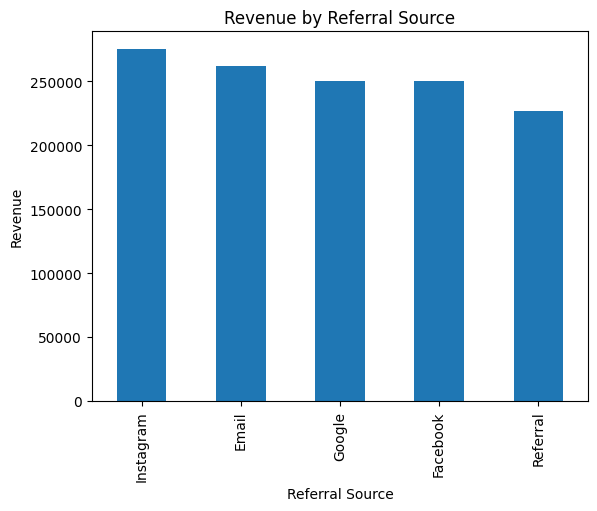

In [36]:
df.groupby('ReferralSource')['TotalPrice'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Revenue by Referral Source')
plt.xlabel('Referral Source')
plt.ylabel('Revenue')
plt.show()

# **Time Analysis**:

In [25]:
df['Month'] = df['Date'].dt.month

In [26]:
df.groupby('Month')['TotalPrice'].sum()

,TotalPrice
Month,
1,124313.23
2,112344.78
3,123840.93
4,109186.05
5,135142.59
6,170616.13
7,85784.64
8,86343.21
9,69321.65


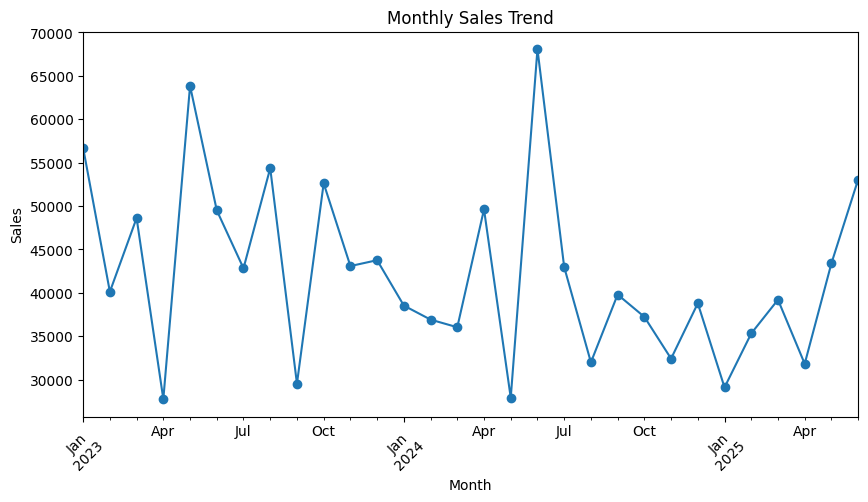

In [37]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['TotalPrice'].sum()
monthly_sales.plot(kind='line', marker='o', figsize=(10,5))
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

# **Items in Cart Analysis**

In [27]:
df['ItemsInCart'].mean()

np.float64(5.485)

In [28]:
df[['ItemsInCart', 'TotalPrice']].corr()

,ItemsInCart,TotalPrice
ItemsInCart,1.00000,0.39254
TotalPrice,0.39254,1.00000


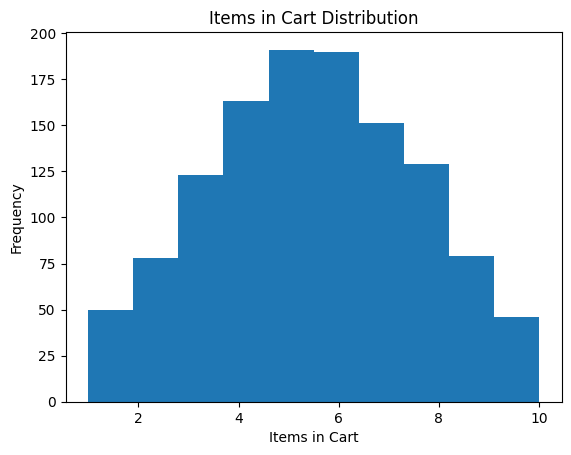

In [38]:
df['ItemsInCart'].plot(kind='hist', bins=10)
plt.title('Items in Cart Distribution')
plt.xlabel('Items in Cart')
plt.show()

# **Outlier Detection**

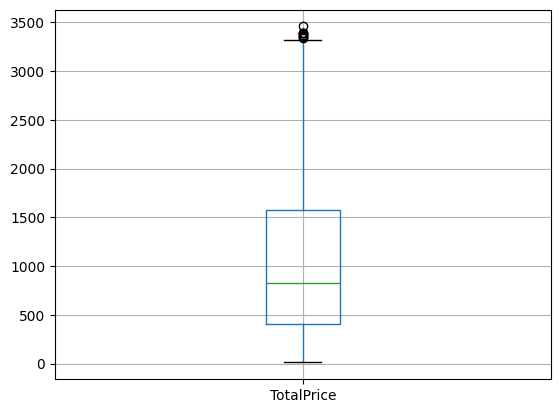

In [29]:

df.boxplot(column='TotalPrice')
plt.show()

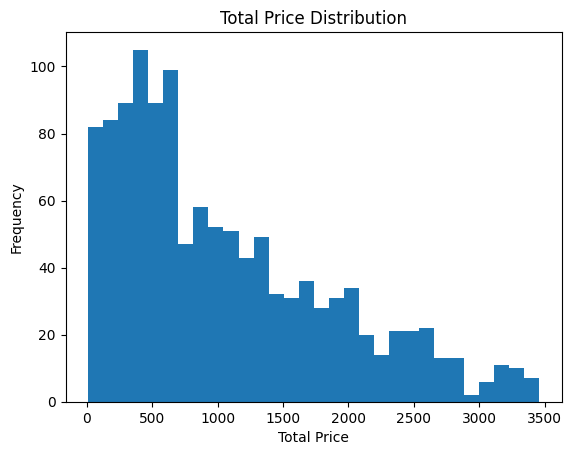

In [40]:
df['TotalPrice'].plot(kind='hist', bins=30)
plt.title('Total Price Distribution')
plt.xlabel('Total Price')
plt.show()

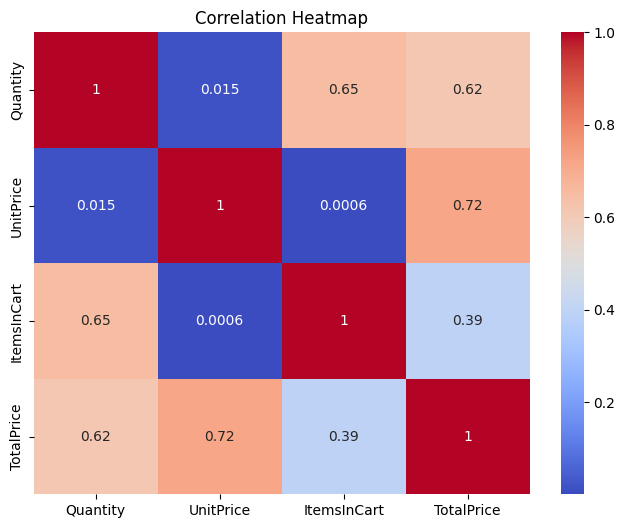

In [42]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()